In [1]:
%matplotlib ipympl

import mujoco
import time
import itertools
import numpy as np
from numpy import pi, sin, cos
import mediapy as media
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
import enum
from tqdm import tqdm

import os
os.environ['MUJOCO_GL'] = 'osmesa'
os.environ['__NV_PRIME_RENDER_OFFLOAD'] = '1'
os.environ['__GLX_VENDOR_LIBRARY_NAME'] = 'nvidia'

model_dir = Path("mujoco_menagerie/boston_dynamics_spot/scene_arm.xml")
model_xml = model_dir / "scene_arm.xml"
model = mujoco.MjModel.from_xml_path(str(model_dir))
data = mujoco.MjData(model)

class Resolution(enum.Enum):
  SD = (480, 640)
  HD = (720, 1280)
  UHD = (2160, 3840)

res = Resolution.SD
h, w = res.value

model.vis.global_.offheight = h
model.vis.global_.offwidth = w
camera = mujoco.MjvCamera()
mujoco.mjv_defaultFreeCamera(model, camera)
# camera.azimuth = -90
# camera.elevation = 0
camera.distance = 3

renderer = mujoco.Renderer(model, height=h, width=w)

In [2]:
joints = ["arm_sh0", "arm_sh1", "arm_el0", "arm_el1", "arm_wr0", "arm_wr1", "arm_f1x"]
bodies = ["arm_link_sh0", "arm_link_sh1", "arm_link_el0", "arm_link_el1", "arm_link_wr0", "arm_link_wr1", "arm_link_fngr"]

class DH_params():
    def __init__(self):
        self.a = np.zeros(6)
        self.d = np.zeros(6)
        self.alpha = np.zeros(6)
        self.theta = np.zeros(6)
    def add_theta(self, q):
        self.theta += q
    def dh_matrix(self, i):
        return np.array([
            [cos(self.theta[i]),    -sin(self.theta[i])*cos(self.alpha[i]),     sin(self.theta[i])*sin(self.alpha[i]),      self.a[i]*cos(self.theta[i])],
            [sin(self.theta[i]),    cos(self.theta[i])*cos(self.alpha[i]),      -cos(self.theta[i])*sin(self.alpha[i]),     self.a[i]*sin(self.theta[i])],
            [0,                     sin(self.alpha[i]),                         cos(self.alpha[i]),                         self.d[i]],
            [0,                     0,                                          0,                                          1]
            ])
       

l1 = 0.12
l2 = 0.339
l3 = 0.403
h3 = 0.075
l5 = 0.117

DH = DH_params()
DH.alpha = np.array([   -pi/2,  0,      pi/2,   pi/2,   -pi/2,  pi/2])
DH.a = np.array([       0,      l2,     h3,     0,      0,      0])
DH.d = np.array([       l1,     0,      0,      l3,     0,      l5])
DH.theta = np.array([   0.0,    pi,    -pi/2,   pi,     0.0,    0.0])

DH.add_theta(np.array([0, -pi, pi, 0, 0, 0]))

def calc_Jacobian(DH_params, p_endeff):
    # p_endeff = data.body("arm_link_fngr").xpos - data.body("arm_link_sh0").xpos
    J = np.zeros((6, 6))
    T = np.eye(4)
    for i in range(6):
        A = DH_params.dh_matrix(i)
        T = T @ A
        z_i = T[0:3, 2]
        p_i = T[0:3, 3]
        J[0:3, i] = np.dot(z_i, (p_endeff - p_i))
        J[3:6, i] = z_i
    return J

def print_p_q(bodies, joints):
    p0 = data.body("arm_link_sh0").xpos
    for body, joint in zip(bodies, joints):
        print(f'{body}\t{np.round(data.body(body).xpos, 3)}\t{np.round(data.joint(joint).qpos, 3)}')


""

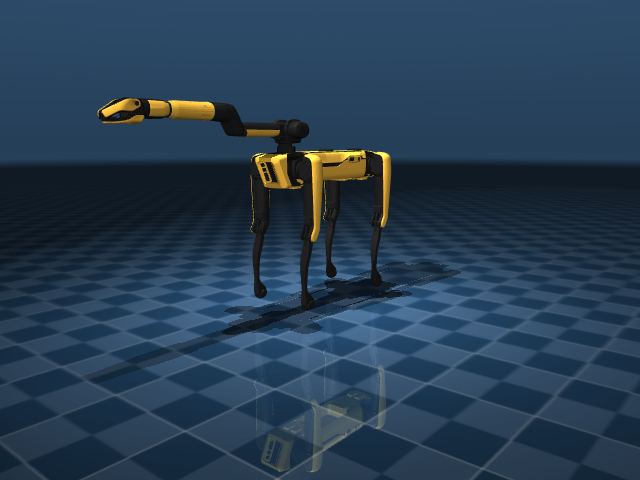

arm_link_sh0	[0.292 0.    0.938]	[0.]
arm_link_sh1	[0.292 0.    0.938]	[0.]
arm_link_el0	[0.631 0.    0.938]	[0.]
arm_link_el1	[1.034 0.    1.013]	[0.]
arm_link_wr0	[1.034 0.    1.013]	[0.]
arm_link_wr1	[1.034 0.    1.013]	[0.]
arm_link_fngr	[1.151 0.    1.028]	[0.]

Initial forward kinematics: [0.859 0.    0.045]


In [3]:
mujoco.mj_forward(model, data)
renderer.update_scene(data, camera)
media.show_image(renderer.render())

print_p_q(bodies, joints)

T = np.eye(4)
for i in range(6):
    A = DH.dh_matrix(i)
    T = T @ A
print(f'\nInitial forward kinematics: {np.round(T[0:3, 3], 3)}')

""

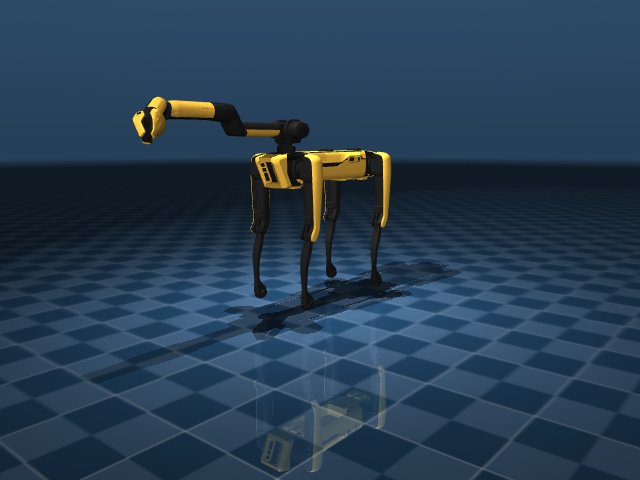

arm_link_sh0	[0.292 0.    0.938]	[0.]
arm_link_sh1	[0.292 0.    0.938]	[0.]
arm_link_el0	[0.631 0.    0.938]	[0.]
arm_link_el1	[1.034 0.    1.013]	[0.785]
arm_link_wr0	[1.034 0.    1.013]	[0.785]
arm_link_wr1	[1.034 0.    1.013]	[0.785]
arm_link_fngr	[1.124 0.046 0.952]	[0.]


In [ ]:
set_q = np.array([0., 0., 0., 0., 0., 0.])
for i, joint in zip(range(0, 6), joints):
    data.joint(joint).qpos = set_q[i]

mujoco.mj_forward(model, data)
renderer.update_scene(data, camera)
media.show_image(renderer.render())

print_p_q(bodies, joints)

In [5]:
DH.add_theta(set_q)
T = np.eye(4)
for i in range(6):
    A = DH.dh_matrix(i)
    T = T @ A
p = T[0:3, 3]
print(f'p:\t{np.round(p, 3)}')

R = T[0:3, 0:3]
# print(np.round(R, 3))
theta = np.arccos(R[2, 2])
if ((R[2, 2] != 1) and (R[2, 2] != -1)):
    phi = np.atan2(R[1, 2], R[0, 2])
    psi = np.atan2(R[2, 1], -R[2, 0])
print(f'phi:\t{np.round(phi,3)}\ntheta:\t{np.round(theta,3)}\npsi:\t{np.round(psi,3)}')

p:	[ 0.825  0.059 -0.013]
phi:	0.285
theta:	0.548
psi:	-1.286


In [6]:
T4 = np.eye(4)
for i in range(4):
    A = DH.dh_matrix(i)
    T4 = T4 @ A
p4 = T4[0:3, 3]
print(f'p4:\t{np.round(p4, 3)}')
print(l1)

R03 = T4[0:3, 0:3]
R36 = np.transpose(R03) * R     # R is R06
# print(np.round(R36, 3))

# b = p4[2] - l1
b = data.body(bodies[4]).xpos[2] - data.body(bodies[0]).xpos[2]
c = np.sqrt(p[0]**2 + p[1]**2)
# p10 = data.body(bodies[1]).xpos - data.body(bodies[0]).xpos
# p40 = data.body(bodies[4]).xpos - data.body(bodies[0]).xpos
a = np.sqrt(p4[0]**2 + p4[1]**2 + p4[2]**2)
beta4 = np.atan2(l3, h3)
d4 = np.sqrt(h3**2 + l3**2)
O3s = pi/2 - DH.theta[2] + beta4
# cosO3s = (b**2 + c**2 - l2**2 - d4**2) / -(2 * l2 * d4)
cosO3s = a**2 - l2**2 - d4**2 + 2 * l2 * d4

q1 = np.atan2(p4[1], p4[0])
# q2 = (np.atan2(b, c) - np.atan2(d4 * sin(O3s), l2 + d4 * cosO3s))
q2 = np.atan2(b, c) - np.arccos((a**2 + d4**2 - l2**2) / (2 * a * d4))
# q3 = pi/2 + beta4 - np.atan2(np.sqrt(1 - cosO3s**2), cosO3s)
q3 = np.arccos(cosO3s) - pi/2 - beta4
print('q123:', np.round(q1, 3), np.round(q2, 3), np.round(q3, 3))

q4 = np.atan2(np.sqrt(1 - (R36[2, 2])**2), R[2, 2]) - pi/2
q5 = np.atan2(R36[1, 2], R36[2, 2]) - pi/2
q6 = np.atan2(R36[2, 1], -R36[2, 0]) - pi/2
print('q456:', np.round(q4, 3), np.round(q5, 3), np.round(q6, 3))

p4:	[0.742 0.    0.045]
0.12
q123: 0.0 -0.02 -1.966
q456: -0.819 -1.571 -3.142
